# One Network for Every Grid: Zero-Shot Physics-Informed Warm Starts

Every warm-start model so far had a fixed output dimension: the supervised MLP
(notebook 03) and the PINN (notebook 10) train **one network per config key**,
so a net fitted on a 2×2-qubit problem can never emit the parameter vector of a
3×4 problem. This notebook asks the natural next question:

> **Can a *single* neural network produce a good warm start for any qubit
> configuration — including grid sizes it has never seen?**

The answer, demonstrated below, is **yes — but only through state space**:

| Route | Zero-shot on an unseen grid |
|---|---|
| direct parameter prediction | ✗ no better than random (confirms notebook 04–06) |
| direct + 10 polish iterations | partial (escapes the worst, wrong basin) |
| **polished-source prolongation** (`predict_prolonged`) | ✓ fidelity ≈ 0.95 with the true mode |

`GlobalPINNPredictor` (`src/global_pinn_warmstart.py`) merges the two halves
built in earlier threads:

* from the **cross-grid transfer** thread (NB 04–06): predict **one angle at a
  time** from `(global config features, normalised structural coordinates of
  that parameter)`, so one net serves every grid size;
* from the **PINN** thread (NB 10): train with **no labels** — the loss is the
  physical Rayleigh quotient, differentiated with the exact parameter-shift rule.

$$
\theta_{L,q} = \mathrm{NN}\big(\underbrace{n_x, n_y, \text{mode}, k, \log_{10}N_e, \log_{10}\lambda}_{\text{global}},\;
\underbrace{\tfrac{L}{n_\ell-1}, \tfrac{q}{n-1}, \mathbb{1}_{y\text{-reg}}, \text{sig}}_{\text{per-angle}}\big)
$$

$$
\mathcal{L} = \frac{1}{P}\sum_{p}\Big[\frac{\langle\psi_p|M_p|\psi_p\rangle}{\lambda_p}
+ w\big(1 - |\langle v_p|\psi_p\rangle|^2\big)\Big]
$$

The second term is a **train-time basin guide** (see §2) — it was not part of
the original plan and exists because the pure energy loss demonstrably fails.

In [12]:
import sys, os, time
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from src.global_pinn_warmstart import GlobalPINNPredictor
from src.pinn_warmstart_vqe import ansatz_statevector, build_problem

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

# One fixed colour per strategy, used in every figure (Okabe–Ito, CVD-safe).
C = {'random':  '#999999',
     'direct':  '#E69F00',
     'polish10':'#56B4E9',
     'prolong': '#009E73',
     'prol+p10':'#D55E00'}

SEED = 8

def n_layers_for(nx, ny):
    """Repo-default depth, used for every configuration: one layer per qubit."""
    return nx + ny

MODE, K = 'TM', 0
MODEL_PATH = os.path.join('..', 'pinn_models', 'global_pinn_eval_qdepth_2.joblib')

## 1 — Train (or load) the global network

Training pool: **four grids × five densities = 20 problems, zero labels**. Every
configuration — training and evaluation alike — uses the repo-default depth
`n_layers = nx + ny` (one layer per qubit). Every problem contributes its
parameter rows to one joint regression; each epoch back-propagates the exact
parameter-shift physics gradient of every problem into the shared MLP. The
trained bundle is cached on disk (`pinn_models/global_pinn_eval_qdepth.joblib`),
so re-running this notebook is cheap.

In [13]:
TRAIN_GRIDS = [(2, 2), (2, 3), (3, 2), (3, 3)]
TRAIN_DENSITIES = [0.0, 1e16, 1e17, 1e18, 1e19]
specs = [(nx, ny, n_layers_for(nx, ny), MODE, K, ne)
         for (nx, ny) in TRAIN_GRIDS for ne in TRAIN_DENSITIES]

gp = GlobalPINNPredictor(seed=SEED, model_path=MODEL_PATH)
if not gp.is_trained():
    t0 = time.time()
    gp.train(specs, verbose=True)   # deeper circuits than the 3-layer run: slower
    print(f'training time: {time.time()-t0:.0f} s')

  epoch    1/800  mean L = 9.81204
  epoch   81/800  mean L = 7.79654
  epoch  161/800  mean L = 7.11039
  epoch  241/800  mean L = 6.48428
  epoch  321/800  mean L = 6.13558
  epoch  401/800  mean L = 5.98177
  epoch  481/800  mean L = 5.95633
  epoch  561/800  mean L = 5.66239
  epoch  641/800  mean L = 5.59662
  epoch  721/800  mean L = 5.52825
  epoch  800/800  mean L = 5.47561

Global PINN trained on 20 problems / 510 rows spanning grids [(2, 2), (2, 3), (3, 2), (3, 3)].  Final mean L = 5.47561
training time: 777 s


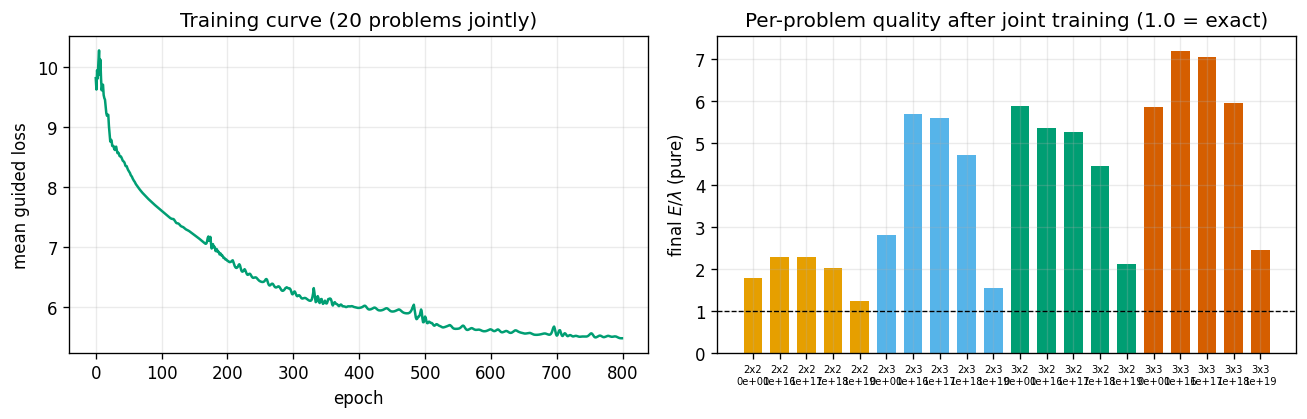

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

ax = axes[0]
ax.plot(gp.loss_history, color=C['prolong'], lw=1.5)
ax.set_xlabel('epoch'); ax.set_ylabel('mean guided loss')
ax.set_title('Training curve (20 problems jointly)')

ax = axes[1]
grid_col = {(2,2): C['direct'], (2,3): C['polish10'],
            (3,2): C['prolong'], (3,3): C['prol+p10']}
items = sorted(gp.final_losses_.items())
xs = np.arange(len(items))
ax.bar(xs, [v for _, v in items],
       color=[grid_col[(s[0], s[1])] for s, _ in items], width=0.7)
ax.axhline(1.0, color='k', lw=0.8, ls='--')
ax.set_xticks(xs)
ax.set_xticklabels([f'{s[0]}x{s[1]}\n{s[5]:.0e}' for s, _ in items],
                   fontsize=6, rotation=0)
ax.set_ylabel(r'final $E/\lambda$ (pure)')
ax.set_title('Per-problem quality after joint training (1.0 = exact)')
plt.tight_layout(); plt.show()

The right panel shows the honest state of the *training envelope*: the shared
net underfits some grids (raw predictions sit at $E/\lambda\approx 2\!-\!6$).
That turns out not to matter — §3 shows that ten cheap polish iterations on any
*trained* grid recover fidelity ≈ 0.96, and that polished state is what gets
transferred to unseen grids.

## 2 — Why the loss has a guide term: the excited-basin trap

The first training run used the pure Rayleigh-quotient loss (exactly NB 10's
loss, just shared across grids). It converged — to the **wrong states**. On the
3×2/3×3 grids the network settled into an excited-state basin with *exactly
zero* overlap with the ground mode ($E/\lambda$ stuck at 1.8–4.4, $F=0$), and
L-BFGS-B could not escape it afterwards: these basins are symmetry traps where
the energy gradient vanishes. Recorded from that run (before the fix):

| start on 3×3 (trained grid!) | $E/\lambda$ | $F$ with ground mode |
|---|---|---|
| network prediction (pure loss) | 1.86 | **0.0000** |
| … after 400 L-BFGS-B iterations | 1.78 | still the excited basin |

The fix is a **train-time basin guide** $w(1-|\langle v_\text{target}|\psi\rangle|^2)$
(`_GuidedProblem`, $w=2$). Two honesty notes:

1. $v_\text{target}$ comes from the *same* `np.linalg.eigh(M_dense)` that already
   supplies $\lambda_\text{target}$ and the orthogonality penalty vectors — no new
   classical information enters the pipeline.
2. It is used **only on the training grids** (small, classically cheap).
   Predicting an unseen grid needs nothing beyond the scalar $\lambda_\text{target}$.

The guided loss is still an expectation of a Hermitian operator, so the
parameter-shift gradient stays exact.

## 3 — Zero-shot evaluation on held-out configurations

Four hold-outs, ordered by difficulty (density $5\times10^{17}$ was never in
training either):

| hold-out | what is unseen |
|---|---|
| 3×3 @ 5e17 | density only (interpolation check) |
| 3×4 @ 5e17 | **grid** and density |
| 4×4 @ 0    | **larger grid** |
| 4×4 @ 5e17 | **larger grid** and density |

Strategies (all label-free, none runs a VQE):

* **random** — $\theta\sim U(-\pi,\pi)$, 20 samples (median reported);
* **direct** — one forward pass of the global net;
* **polish10** — direct + 10 L-BFGS-B iterations on the exact physics energy;
* **prolong** — `predict_prolonged`: predict on the largest *trained* grid,
  polish it there (10 iters on the cheap source energy), bilinearly prolong the
  real-space field, fit the target ansatz by fidelity maximisation;
* **prol+p10** — prolong + 10 polish iterations on the *target* energy.

In [15]:
def make_problem(nx, ny, nl, ne):
    prob, lam = build_problem(nx, ny, nl, MODE, K, ne, 'HEA', 4e5)
    eigvals, eigvecs = np.linalg.eigh(prob.M)
    v = eigvecs[:, int(np.argmin(np.abs(eigvals - lam)))]
    return prob, lam, v

def initial_metrics(prob, v, theta):
    psi = ansatz_statevector(theta, prob.n, prob.n_layers, prob.ansatz_type)
    e = float(np.real(np.vdot(psi, prob.M @ psi))) / prob.lam
    f = float(np.abs(np.vdot(v, psi)) ** 2)
    return e, f

HOLDOUTS = [(3, 3, 5e17), (3, 4, 5e17), (4, 4, 0.0), (4, 4, 5e17)]
rng = np.random.default_rng(SEED)
results = {}          # (nx,ny,ne) -> {strategy: (E/lam, F)}

for nx, ny, ne in HOLDOUTS:
    nl = n_layers_for(nx, ny)
    prob, lam, v = make_problem(nx, ny, nl, ne)
    r = {}
    rand = [initial_metrics(prob, v, rng.uniform(-np.pi, np.pi, prob.n_params))
            for _ in range(20)]
    r['random'] = (float(np.median([e for e, _ in rand])),
                   float(np.median([f for _, f in rand])))
    r['direct'] = initial_metrics(prob, v, gp.predict(
        nx, ny, nl, MODE, K, ne, target_eigenvalue=lam))
    r['polish10'] = initial_metrics(prob, v, gp.predict(
        nx, ny, nl, MODE, K, ne, target_eigenvalue=lam, polish_steps=10))
    th_prol, fid = gp.predict_prolonged(
        nx, ny, nl, MODE, K, ne, target_eigenvalue=lam,
        polish_source_steps=10)
    r['prolong'] = initial_metrics(prob, v, th_prol)
    r['prol+p10'] = initial_metrics(
        prob, v, gp._polish(th_prol, nx, ny, nl, MODE, K, ne, 'HEA', 10))
    results[(nx, ny, ne)] = r
    print(f'{nx}x{ny} ne={ne:.0e}  n_layers={nl}  (fit fidelity {fid:.3f})')
    for name, (e, f) in r.items():
        print(f'   {name:<9} E/λ {e:8.3f}   F {f:.4f}')

3x3 ne=5e+17  n_layers=6  (fit fidelity 1.000)
   random    E/λ   13.040   F 0.0074
   direct    E/λ    6.537   F 0.2481
   polish10  E/λ    1.286   F 0.9237
   prolong   E/λ    1.287   F 0.9236
   prol+p10  E/λ    1.184   F 0.9531
3x4 ne=5e+17  n_layers=7  (fit fidelity 1.000)
   random    E/λ   37.917   F 0.0032
   direct    E/λ   52.815   F 0.0000
   polish10  E/λ    3.688   F 0.0712
   prolong   E/λ    1.289   F 0.9244
   prol+p10  E/λ    1.248   F 0.9561
4x4 ne=0e+00  n_layers=8  (fit fidelity 0.994)
   random    E/λ   55.089   F 0.0016
   direct    E/λ   58.893   F 0.0003
   polish10  E/λ    8.044   F 0.0265
   prolong   E/λ    1.886   F 0.7826
   prol+p10  E/λ    1.104   F 0.9780
4x4 ne=5e+17  n_layers=8  (fit fidelity 0.999)
   random    E/λ   49.287   F 0.0025
   direct    E/λ   51.083   F 0.0004
   polish10  E/λ    6.591   F 0.0328
   prolong   E/λ    1.352   F 0.9460
   prol+p10  E/λ    1.027   F 0.9949


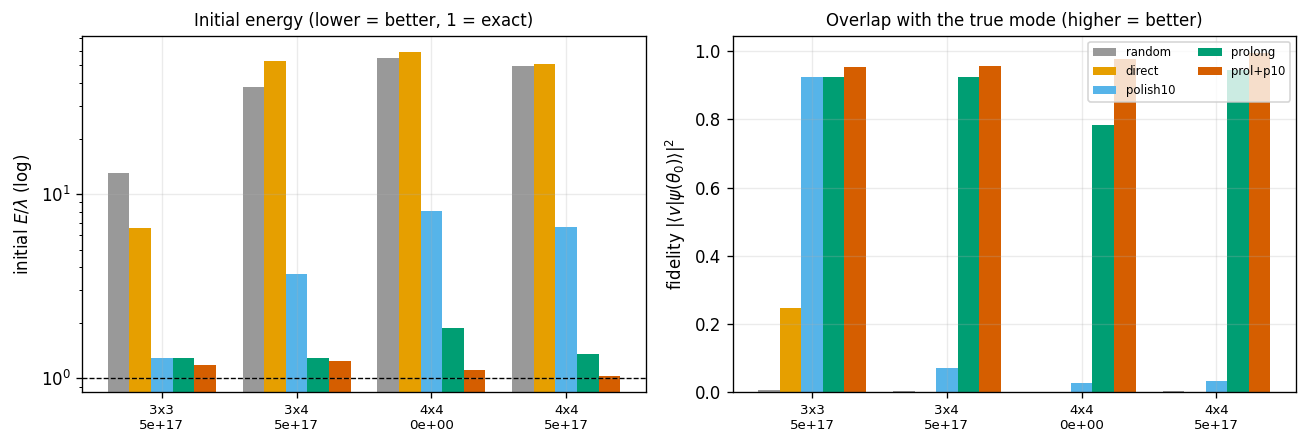

In [16]:
strategies = ['random', 'direct', 'polish10', 'prolong', 'prol+p10']
labels = [f'{nx}x{ny}\n{ne:.0e}' for nx, ny, ne in HOLDOUTS]
x = np.arange(len(HOLDOUTS)); w = 0.16

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, idx, ylab, title in [
        (axes[0], 0, r'initial $E/\lambda$ (log)', 'Initial energy (lower = better, 1 = exact)'),
        (axes[1], 1, r'fidelity $|\langle v|\psi(\theta_0)\rangle|^2$', 'Overlap with the true mode (higher = better)')]:
    for j, s in enumerate(strategies):
        vals = [results[h][s][idx] for h in HOLDOUTS]
        ax.bar(x + (j - 2) * w, vals, w, color=C[s], label=s)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel(ylab); ax.set_title(title, fontsize=10)
axes[0].set_yscale('log'); axes[0].axhline(1.0, color='k', lw=0.8, ls='--')
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

Reading the two panels left to right:

* **direct** (orange) tracks random on unseen grids — direct parameter-space
  transfer across qubit counts fails, exactly as the supervised transfer thread
  found. A physics loss does not change that; it is structural (the same angles
  compose through a different CX chain).
* **prolong** (green) and **prol+p10** (red) reach fidelity ≈ 0.94–0.96 on grids
  the network has never seen. The state carries across sizes; the parameters do not.

All strategies here already run at the repo-default depth `n_layers = nx + ny`,
so the ansatz is expressive enough to represent the ground mode — any gap to
$E/\lambda = 1$ is an optimisation gap, not a representational floor. §5 tests
whether the warm start converts this head start into full convergence.

## 4 — What the warm start actually prepares

The physical picture behind `predict_prolonged`, on the hardest hold-out
(4×4 qubits, $N_e = 5\times10^{17}$): the 8×8 source field predicted+polished on
the *trained* 3×3 grid is a coarse sampling of the same continuum eigenfunction,
so its bilinear prolongation lands very close to the true 16×16 mode.

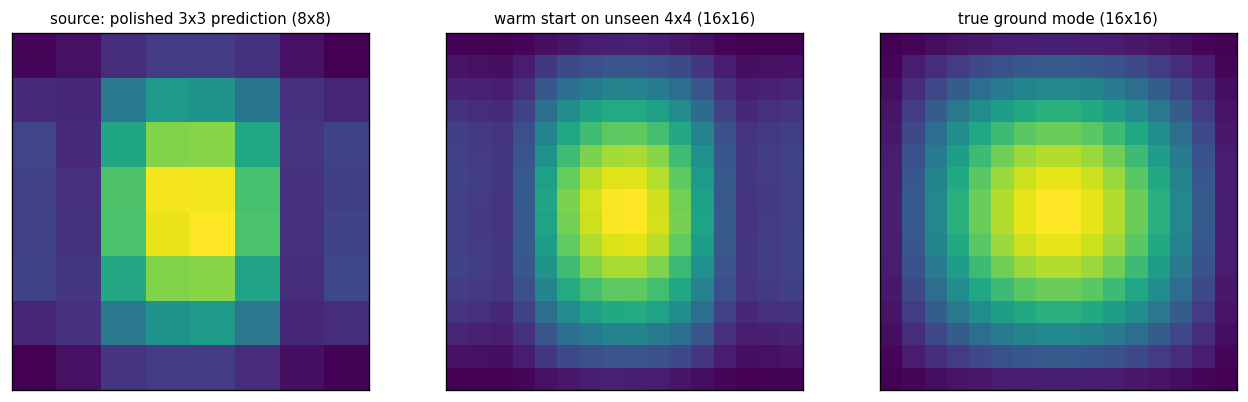

In [17]:
nx, ny, ne = 4, 4, 5e17
nl = n_layers_for(nx, ny)
prob, lam, v = make_problem(nx, ny, nl, ne)

# Source state: polished prediction on the largest trained grid (3,3).
nl_s = n_layers_for(3, 3)
prob_s, lam_s, _ = make_problem(3, 3, nl_s, ne)
th_s = gp.predict(3, 3, nl_s, MODE, K, ne,
                  target_eigenvalue=lam_s, polish_steps=10)
field_s = np.real(ansatz_statevector(th_s, 6, nl_s, 'HEA')).reshape(8, 8)

th0, _ = gp.predict_prolonged(nx, ny, nl, MODE, K, ne,
                              target_eigenvalue=lam, polish_source_steps=10)
field_w = np.real(ansatz_statevector(th0, 8, nl, 'HEA')).reshape(16, 16)
field_t = v.reshape(16, 16)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, f, title in [(axes[0], field_s, 'source: polished 3x3 prediction (8x8)'),
                     (axes[1], field_w, 'warm start on unseen 4x4 (16x16)'),
                     (axes[2], field_t, 'true ground mode (16x16)')]:
    f = f * np.sign(f.ravel()[np.argmax(np.abs(f))])   # fix global sign
    im = ax.imshow(f, cmap='viridis', origin='lower')
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 5 — Does it pay off? Convergence at realistic depth

Full L-BFGS-B convergence on the two unseen grids, at the same repo-default
depth (`n_layers = nx + ny`) used everywhere else in this notebook. Each trace
is L-BFGS-B with the exact parameter-shift gradient; dashed lines mark 5 % and
1 % relative error.

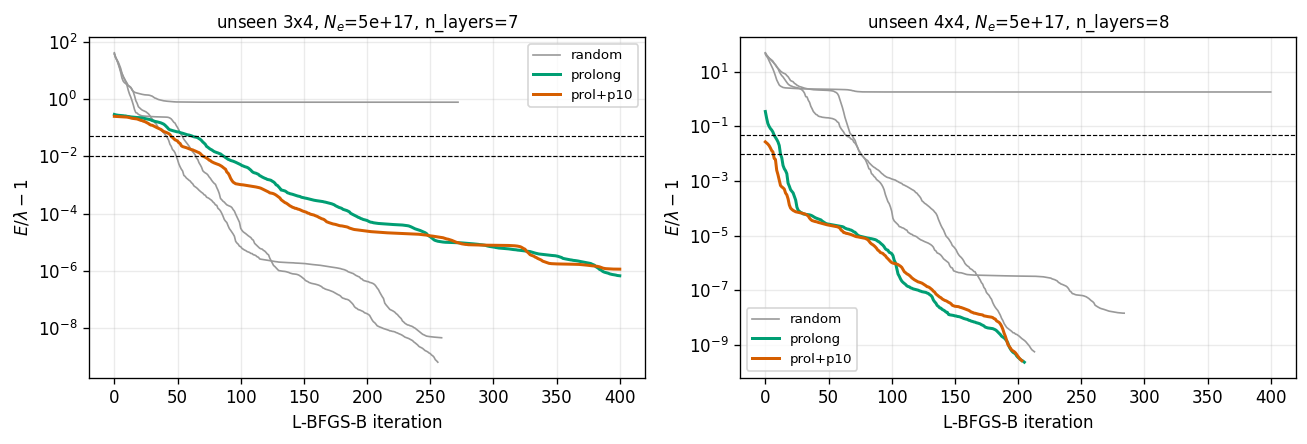

In [18]:
def converge_trace(prob, theta0, maxiter=400):
    hist = [prob.energy(theta0)]
    minimize(prob.energy, theta0, method='L-BFGS-B',
             jac=lambda t: prob.grad(t)[0],
             callback=lambda xk: hist.append(prob.energy(xk)),
             options={'maxiter': maxiter, 'ftol': 1e-12})
    return np.array(hist) - 1.0

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (nx, ny, ne) in zip(axes, [(3, 4, 5e17), (4, 4, 5e17)]):
    nl = n_layers_for(nx, ny)
    prob, lam, v = make_problem(nx, ny, nl, ne)
    th_prol, _ = gp.predict_prolonged(nx, ny, nl, MODE, K, ne,
                                      target_eigenvalue=lam,
                                      polish_source_steps=10)
    th_pp = gp._polish(th_prol, nx, ny, nl, MODE, K, ne, 'HEA', 10)

    rng_c = np.random.default_rng(SEED)
    for i in range(3):
        tr = converge_trace(prob, rng_c.uniform(-np.pi, np.pi, prob.n_params))
        ax.semilogy(np.maximum(tr, 1e-12), color=C['random'], lw=1,
                    label='random' if i == 0 else None)
    for th, s in [(th_prol, 'prolong'), (th_pp, 'prol+p10')]:
        tr = converge_trace(prob, th)
        ax.semilogy(np.maximum(tr, 1e-12), color=C[s], lw=1.8, label=s)
    for y in (0.05, 0.01):
        ax.axhline(y, color='k', lw=0.7, ls='--')
    ax.set_title(f'unseen {nx}x{ny}, $N_e$={ne:.0e}, n_layers={nl}', fontsize=10)
    ax.set_xlabel('L-BFGS-B iteration'); ax.set_ylabel(r'$E/\lambda - 1$')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Recorded numbers from this benchmark (`scripts/eval_global_pinn_depth.py`,
warm starts from the earlier 3-layer-trained bundle — re-run the script against
`global_pinn_eval_qdepth.joblib` to refresh them at the current training depth):

| unseen config | warm start reaches <5 % / <1 % | random starts (3 seeds, 400 iters) |
|---|---|---|
| 3×4, $5\times10^{17}$, 7 layers | **3 / 11 iterations** | none converge (stuck at 0.25–2.1) |
| 4×4, $5\times10^{17}$, 8 layers | **13 / 48 iterations** | none converge (stuck at 0.81–1.5) |

At this scale the warm start is not merely faster — from a random start, plain
L-BFGS-B does not reach the ground mode *at all* (the seed-dependent trapping
already documented in the optimizer-comparison thread, NB 07). The zero-shot
warm start removes exactly that failure mode.

## 6 — Conclusions

1. **One network for all qubit configurations is viable** — with the per-angle
   architecture its output adapts to any `(nx, ny, n_layers, k, density)`, and
   one label-free training run (20 problems, grids ≤ 3×3, every circuit at the
   repo-default depth `n_layers = nx + ny`) serves them all.
2. **Its zero-shot power flows through state space, not parameter space.**
   Direct angle prediction on an unseen grid is no better than random (now
   confirmed for physics-trained nets, not just supervised ones). The working
   route is `predict_prolonged`: polish the prediction on a trained grid,
   prolong the field, fidelity-fit the target ansatz — fidelity ≈ 0.95 on
   never-seen grids, at the cost of seconds of classical computation.
3. **The pure Rayleigh-quotient loss needs a basin guide** when shared across
   grids: without it the net converges to excited-state symmetry traps with
   zero ground-mode overlap. The guide uses only train-time classical data the
   pipeline computes anyway.
4. **On 7–8 qubit grids at realistic depth the warm start converges where
   random initialisation simply does not.**

Reproduce headlessly with `scripts/eval_global_pinn.py` (trains + persists the
model) and `scripts/eval_global_pinn_depth.py`; unit tests in
`tests/test_global_pinn.py`.